In [1]:
import numpy as np
from pathlib import Path
import os, sys
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import mne

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
cwd = Path.cwd()
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}


In [2]:
task = 'Active'
file_path = f'Fit_{task}_late'
os.makedirs(file_path, exist_ok=True)
    
audibilities_all_parts, state_train_all_parts = [], []
state_train_early_all_parts = []

for part in tqdm(range(20)):
    # part = 18

    # Load data
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref

    # Load metadata
    epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
    audibility = epochs.metadata['audibility'].to_numpy()
    snr = epochs.metadata['snr'].to_numpy()
    audibilities_all_parts.append(audibility)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        state_train = lead.STG(epochs_file, tmin=300, tmax=500, sort_by_snr=False)
        state_train_all_parts.append(state_train)
        state_train_early = lead.STG(epochs_file, tmin=100, tmax=200, sort_by_snr=False)
        state_train_early_all_parts.append(state_train_early)

  0%|          | 0/20 [00:00<?, ?it/s]

/tmp/ipykernel_323590/2383470878.py:16: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_323590/2383470878.py:16: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_323590/2383470878.py:16: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_323590/2383470878.py:16: RuntimeWarni

In [3]:
state_train_dict = {aud: [] for aud in range(11)}
state_train_early_dict = {aud: [] for aud in range(11)}
for part in range(20):
    for aud in np.unique(audibilities_all_parts[part]):
        subset = state_train_all_parts[part][audibilities_all_parts[part] == aud]
        subset_early = state_train_early_all_parts[part][audibilities_all_parts[part] == aud]

        # If the filtered result is a list/array of trials, keep each trial as its own item.
        # If it is already a single trial vector, keep it as a single element.
        if isinstance(subset, np.ndarray):
            if subset.ndim > 1:
                subset = subset.tolist()
                subset_early = subset_early.tolist()
            else:
                subset = [subset]
                subset_early = [subset_early]

        if isinstance(subset, (list, tuple)) and subset and isinstance(subset[0], (list, tuple, np.ndarray)):
            state_train_dict[aud].extend(subset)
            state_train_early_dict[aud].extend(subset_early)
        else:
            state_train_dict[aud].append(subset)
            state_train_early_dict[aud].append(subset_early)


In [4]:
for aud in state_train_dict.keys():
    state_train_dict[aud] = np.array(state_train_dict[aud])
    state_train_early_dict[aud] = np.array(state_train_early_dict[aud])

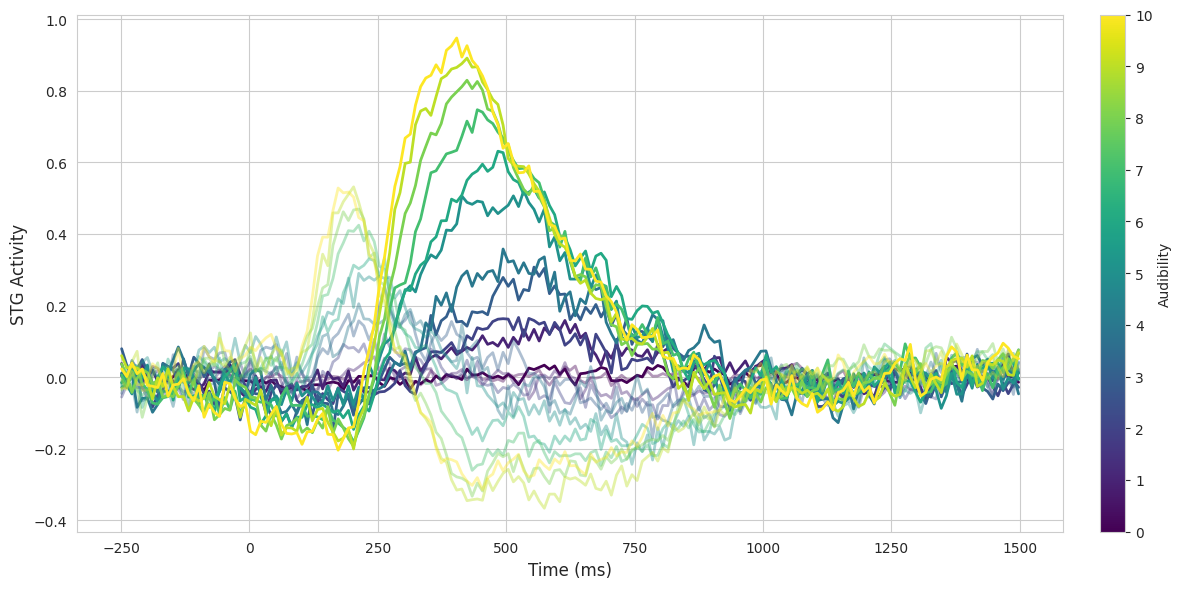

In [5]:
times = np.linspace(-500, 2000, 250)

plt.figure(figsize=(13, 6))
sns.set_style('whitegrid')

cmap = plt.get_cmap('viridis')
norm = plt.Normalize(0, 10)

for aud in range(11):
    signal = state_train_dict[aud].mean(axis=0)
    plt.plot(
        times[25:200],
        signal[25:200],
        color=cmap(norm(aud)),
        linewidth=2,
        alpha=1,
    )

    signal_early = state_train_early_dict[aud].mean(axis=0)
    plt.plot(
        times[25:200],
        signal_early[25:200],
        color=cmap(norm(aud)),
        linewidth=2,
        alpha=0.4,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
colorbar = plt.colorbar(sm, ax=plt.gca(), pad=0.03)
colorbar.set_label('Audibility')
colorbar.set_ticks(np.arange(0, 11, 1))

plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('STG Activity', fontsize=12)
# plt.title(f'STG Activity by Audibility', fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
inter_trial_std_dict = {aud: [] for aud in range(11)}
for part in tqdm(range(20)):
    for aud in range(11):
        inter_trial_std = np.std(state_train_all_parts[part][audibilities_all_parts[part]==aud], axis=0)
        # print(f"Part {part}, Audibility {aud}: inter_trial_std shape: {inter_trial_std.shape}")
        inter_trial_std_dict[aud].append(inter_trial_std)

for aud in inter_trial_std_dict.keys():
    inter_trial_std_dict[aud] = np.array(inter_trial_std_dict[aud])

# 95% confidence interval for the variability mean at each audibility level.
# Most common approach: mean +/- 1.96 * SEM, where SEM = SD / sqrt(n)
window = (times >= 400) & (times <= 500)

mean_variability_by_aud = []
ci95_by_aud = []

for aud in range(11):
    if inter_trial_std_dict[aud].size == 0:
        mean_variability_by_aud.append(np.nan)
        ci95_by_aud.append(np.nan)
        continue

    subject_window_means = np.array([
        np.mean(subj_std[window])
        for subj_std in inter_trial_std_dict[aud]
    ])

    mean_val = subject_window_means.mean()
    if subject_window_means.size > 1:
        sem = subject_window_means.std(ddof=1) / np.sqrt(subject_window_means.size)
        ci95 = 1.96 * sem
    else:
        ci95 = 0.0

    mean_variability_by_aud.append(mean_val)
    ci95_by_aud.append(ci95)

  0%|          | 0/20 [00:00<?, ?it/s]

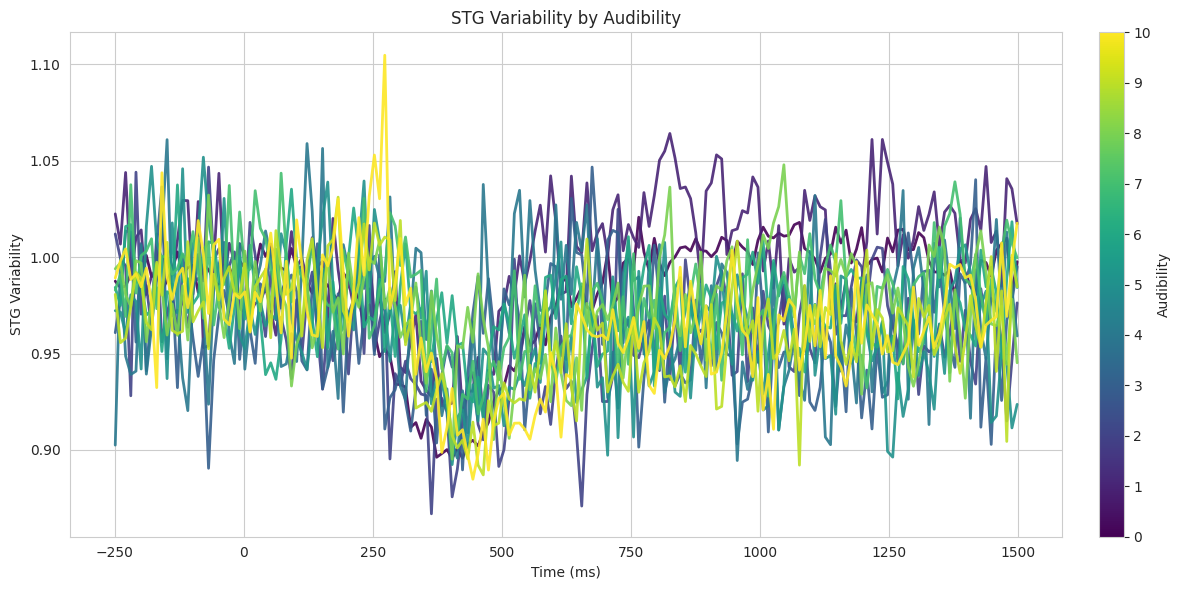

In [7]:
times = np.linspace(-500, 2000, 250)

plt.figure(figsize=(13, 6))
sns.set_style('whitegrid')

cmap = plt.get_cmap('viridis')
norm = plt.Normalize(0, 10)

for aud in range(11):
    signal = inter_trial_std_dict[aud].mean(axis=0)
    plt.plot(
        times[25:200],
        signal[25:200],
        color=cmap(norm(aud)),
        linewidth=2,
        alpha=0.9,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
colorbar = plt.colorbar(sm, ax=plt.gca(), pad=0.03)
colorbar.set_label('Audibility')
colorbar.set_ticks(np.arange(0, 11, 1))

plt.xlabel('Time (ms)')
plt.ylabel('STG Variability')
plt.title(f'STG Variability by Audibility')
plt.tight_layout()
plt.show()

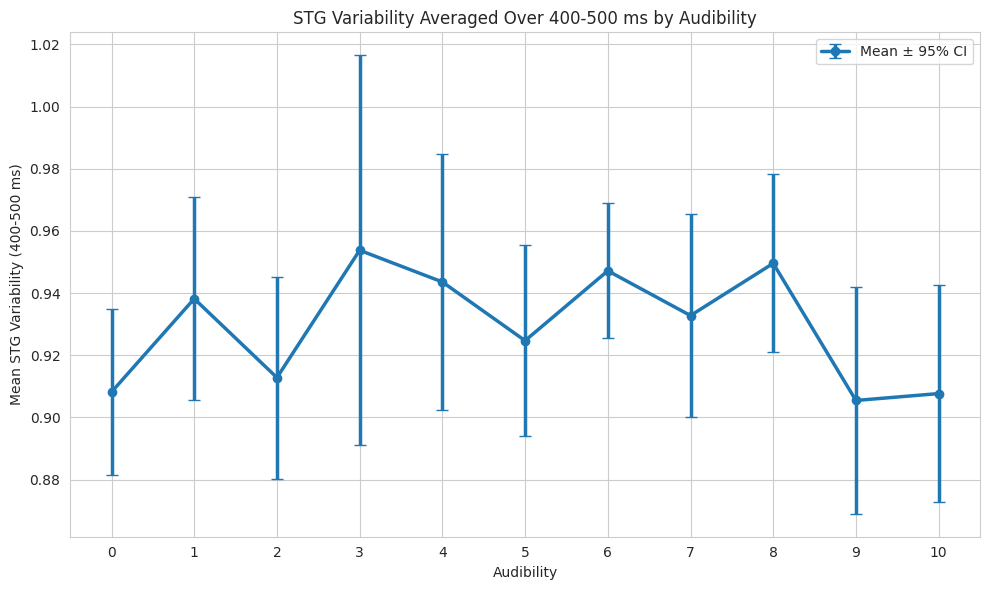

In [8]:
# variability averaged over the 400-500 ms window, for each audibility level, with 95% CI
mean_variability_by_aud = np.asarray(mean_variability_by_aud, dtype=float)
ci95_by_aud = np.asarray(ci95_by_aud, dtype=float)
valid = ~np.isnan(mean_variability_by_aud)

plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

plt.errorbar(
    np.arange(11)[valid],
    mean_variability_by_aud[valid],
    yerr=ci95_by_aud[valid],
    fmt='o-',
    capsize=4,
    markersize=6,
    linewidth=2.5,
    color='C0',
    label='Mean ± 95% CI'
)

plt.xticks(np.arange(11))
plt.xlabel('Audibility')
plt.ylabel('Mean STG Variability (400-500 ms)')
plt.title('STG Variability Averaged Over 400-500 ms by Audibility')
plt.legend()
plt.tight_layout()
plt.show()

# The sorted_by_snr counterpart

In [9]:
task = 'Active'
file_path = f'Fit_{task}_late'
os.makedirs(file_path, exist_ok=True)
    
snrs_all_parts_snrwise, state_train_all_parts_snrwise = [], []
state_train_all_parts_snrwise_early = []

for part in tqdm(range(20)):
    # part = 18

    # Load data
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref

    # Load metadata
    epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
    audibility = epochs.metadata['audibility'].to_numpy()
    snr = epochs.metadata['snr'].to_numpy()
    snrs_all_parts_snrwise.append(snr)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        state_train = lead.STG(epochs_file, tmin=300, tmax=500, sort_by_snr=True)
        state_train_all_parts_snrwise.append(state_train)
        state_train_early = lead.STG(epochs_file, tmin=100, tmax=200, sort_by_snr=True)
        state_train_all_parts_snrwise_early.append(state_train_early)


  0%|          | 0/20 [00:00<?, ?it/s]

/tmp/ipykernel_323590/2655712667.py:16: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_323590/2655712667.py:16: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_323590/2655712667.py:16: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_323590/2655712667.py:16: RuntimeWarni

In [10]:
state_train_dict_snrwise = {snr: [] for snr in range(1, 7)}
state_train_dict_snrwise_early = {snr: [] for snr in range(1, 7)}
for part in range(20):
    for snr in range(1, 7):
        subset = state_train_all_parts_snrwise[part][snr - 1]
        subset_early = state_train_all_parts_snrwise_early[part][snr - 1]

        # If the filtered result is a list/array of trials, keep each trial as its own item.
        # If it is already a single trial vector, keep it as a single element.
        if isinstance(subset, np.ndarray):
            if subset.ndim > 1:
                subset = subset.tolist()
                subset_early = subset_early.tolist()
            else:
                subset = [subset]
                subset_early = [subset_early]

        if isinstance(subset, (list, tuple)) and subset and isinstance(subset[0], (list, tuple, np.ndarray)):
            state_train_dict_snrwise[snr].extend(subset)
            state_train_dict_snrwise_early[snr].extend(subset_early)
        else:
            state_train_dict_snrwise[snr].append(subset)
            state_train_dict_snrwise_early[snr].append(subset_early)

In [11]:
for snr in state_train_dict_snrwise.keys():
    state_train_dict_snrwise[snr] = np.array(state_train_dict_snrwise[snr])
    state_train_dict_snrwise_early[snr] = np.array(state_train_dict_snrwise_early[snr])

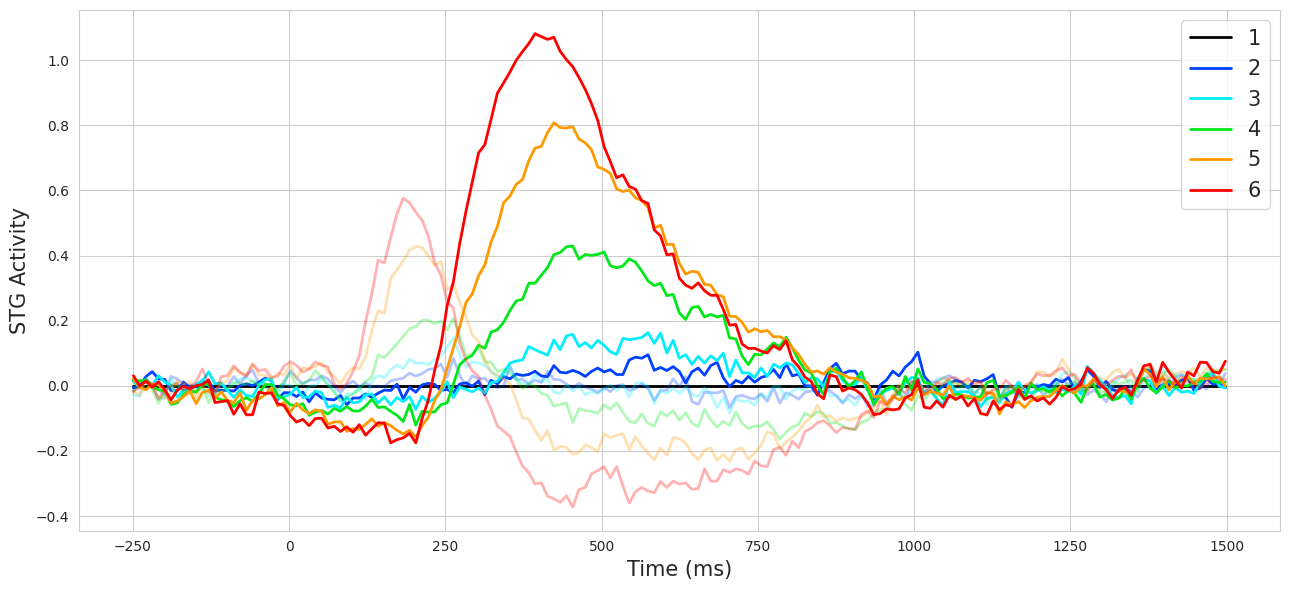

In [12]:
from matplotlib.colors import ListedColormap, Normalize

times = np.linspace(-500, 2000, 250)

plt.figure(figsize=(13, 6))
sns.set_style('whitegrid')

snr_levels = [-13, -11, -9, -7, -5, -3]
custom_colors = [colormap[i] for i in range(1, 7)]
cmap = ListedColormap(custom_colors, name='snr_custom')
norm = Normalize(vmin=1, vmax=6)

for snr in range(1, 7):
    signal = state_train_dict_snrwise[snr].mean(axis=0)
    plt.plot(
        times[25:200],
        signal[25:200],
        color=colormap[snr-1],
        linewidth=2,
        alpha=1,
        label=str(snr)
    )

    signal_early = state_train_dict_snrwise_early[snr].mean(axis=0)
    plt.plot(
        times[25:200],
        signal_early[25:200],
        color=colormap[snr-1],
        linewidth=2,
        alpha=0.3,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
# colorbar = plt.colorbar(sm, ax=plt.gca(), pad=0.03, ticks=np.arange(1, 7))
# colorbar.set_label('SNR (dB)')
# colorbar.set_ticklabels([str(level) for level in snr_levels])

plt.xlabel('Time (ms)', fontsize=15)
plt.ylabel('STG Activity', fontsize=15)
# plt.title(f'STG Activity by SNR', fontsize=12)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

In [13]:
inter_trial_std_dict_snrwise = {snr: [] for snr in range(1, 7)}
for part in tqdm(range(20)):
    for snr in range(1, 7):
        inter_trial_std = np.std(state_train_all_parts_snrwise[part][snr - 1], axis=0)
        # print(f"Part {part}, SNR {snr}: inter_trial_std shape: {inter_trial_std.shape}")
        inter_trial_std_dict_snrwise[snr].append(inter_trial_std)

for snr in inter_trial_std_dict_snrwise.keys():
    inter_trial_std_dict_snrwise[snr] = np.array(inter_trial_std_dict_snrwise[snr])

# 95% confidence interval for the variability mean at each SNR level.
# Most common approach: mean +/- 1.96 * SEM, where SEM = SD / sqrt(n)
window = (times >= 400) & (times <= 500)

mean_variability_by_snr = []
ci95_by_snr = []

for snr in range(1, 7):
    if inter_trial_std_dict_snrwise[snr].size == 0:
        mean_variability_by_snr.append(np.nan)
        ci95_by_snr.append(np.nan)
        continue

    subject_window_means = np.array([
        np.mean(subj_std[window])
        for subj_std in inter_trial_std_dict_snrwise[snr]
    ])

    mean_val = subject_window_means.mean()
    if subject_window_means.size > 1:
        sem = subject_window_means.std(ddof=1) / np.sqrt(subject_window_means.size)
        ci95 = 1.96 * sem
    else:
        ci95 = 0.0

    mean_variability_by_snr.append(mean_val)
    ci95_by_snr.append(ci95)


  0%|          | 0/20 [00:00<?, ?it/s]

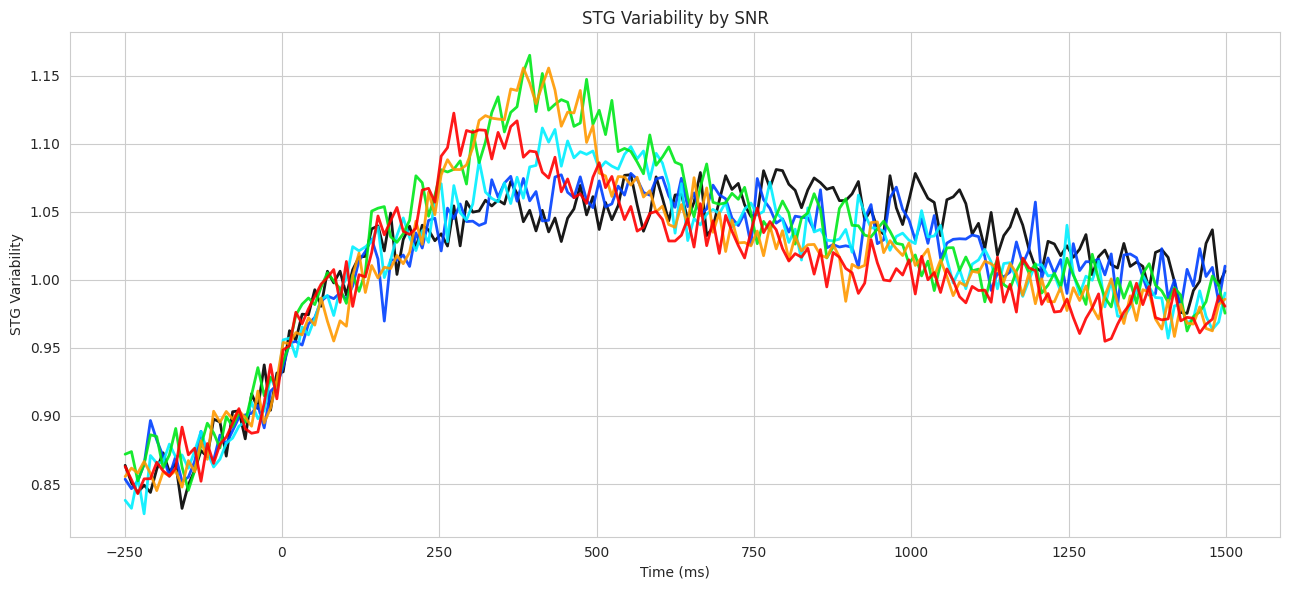

In [14]:
times = np.linspace(-500, 2000, 250)

plt.figure(figsize=(13, 6))
sns.set_style('whitegrid')

snr_levels = [-13, -11, -9, -7, -5, -3]
custom_colors = [colormap[i] for i in range(1, 7)]
cmap = ListedColormap(custom_colors, name='snr_custom')
norm = Normalize(vmin=1, vmax=6)

for snr in range(1, 7):
    signal = inter_trial_std_dict_snrwise[snr].mean(axis=0)
    plt.plot(
        times[25:200],
        signal[25:200],
        color=colormap[snr-1],
        linewidth=2,
        alpha=0.9,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
# colorbar = plt.colorbar(sm, ax=plt.gca(), pad=0.03)
# colorbar.set_label('SNR')
# colorbar.set_ticks(np.arange(1, 7))
# colorbar.set_ticklabels([str(level) for level in snr_levels])

plt.xlabel('Time (ms)')
plt.ylabel('STG Variability')
plt.title(f'STG Variability by SNR')
plt.tight_layout()
plt.show()

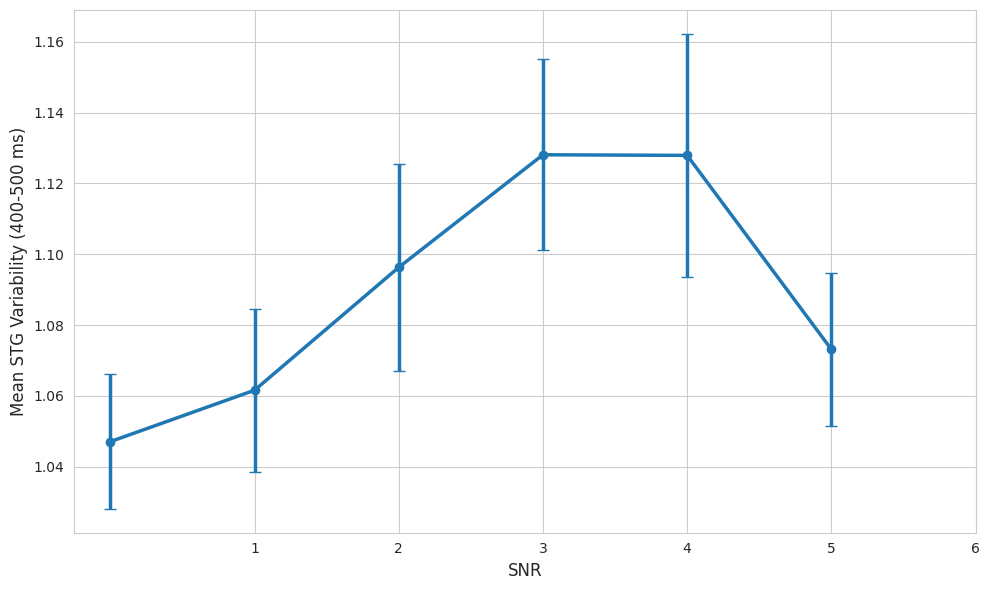

In [15]:
mean_variability_by_snr = np.asarray(mean_variability_by_snr, dtype=float)
ci95_by_snr = np.asarray(ci95_by_snr, dtype=float)
valid = ~np.isnan(mean_variability_by_snr)

plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

plt.errorbar(
    np.arange(0, 6)[valid],
    mean_variability_by_snr[valid],
    yerr=ci95_by_snr[valid],
    fmt='o-',
    capsize=4,
    markersize=6,
    linewidth=2.5,
    color='C0',
    label='Mean ± 95% CI'
)

plt.xticks(np.arange(1, 7))
plt.xlabel('SNR', fontsize=12)
plt.ylabel('Mean STG Variability (400-500 ms)', fontsize=12)
# plt.title('STG Variability Averaged Over 400-500 ms by SNR')
# plt.legend()
plt.tight_layout()
plt.show()

# Passive sorted_by_snr counterpart

In [16]:
task = 'Passive'
file_path = f'Fit_{task}_late'
os.makedirs(file_path, exist_ok=True)
    
snrs_all_parts_passive, state_train_all_parts_passive = [], []
state_train_all_parts_passive_early = []

for part in tqdm(range(20)):
    # part = 18

    # Load data
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref

    # Load metadata
    epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
    snr = epochs.metadata['snr'].to_numpy()
    snrs_all_parts_passive.append(snr)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        state_train = lead.STG(epochs_file, tmin=300, tmax=500, sort_by_snr=True)
        state_train_all_parts_passive.append(state_train)
        state_train_early = lead.STG(epochs_file, tmin=100, tmax=200, sort_by_snr=True)
        state_train_all_parts_passive_early.append(state_train_early)


  0%|          | 0/20 [00:00<?, ?it/s]

/tmp/ipykernel_323590/1490679894.py:16: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_323590/1490679894.py:16: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_323590/1490679894.py:16: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_323590/1490679894.py:16: RuntimeWarni

In [17]:
state_train_dict_passive = {snr: [] for snr in range(7)}
state_train_dict_passive_early = {snr: [] for snr in range(7)}
for part in range(20):
    max_snr = 7 if part>=10 else 6
    for snr in range(1, max_snr + 1):
        subset = state_train_all_parts_passive[part][snr - 1]
        subset_early = state_train_all_parts_passive_early[part][snr - 1]

        # If the filtered result is a list/array of trials, keep each trial as its own item.
        # If it is already a single trial vector, keep it as a single element.
        if isinstance(subset, np.ndarray):
            if subset.ndim > 1:
                subset = subset.tolist()
                subset_early = subset_early.tolist()
            else:
                subset = [subset]
                subset_early = [subset_early]

        if isinstance(subset, (list, tuple)) and subset and isinstance(subset[0], (list, tuple, np.ndarray)):
            state_train_dict_passive[snr-1].extend(subset)
            state_train_dict_passive_early[snr-1].extend(subset_early)
        else:
            state_train_dict_passive[snr-1].append(subset)
            state_train_dict_passive_early[snr-1].append(subset_early)


In [18]:
for snr in state_train_dict_passive.keys():
    state_train_dict_passive[snr] = np.array(state_train_dict_passive[snr])
    state_train_dict_passive_early[snr] = np.array(state_train_dict_passive_early[snr])


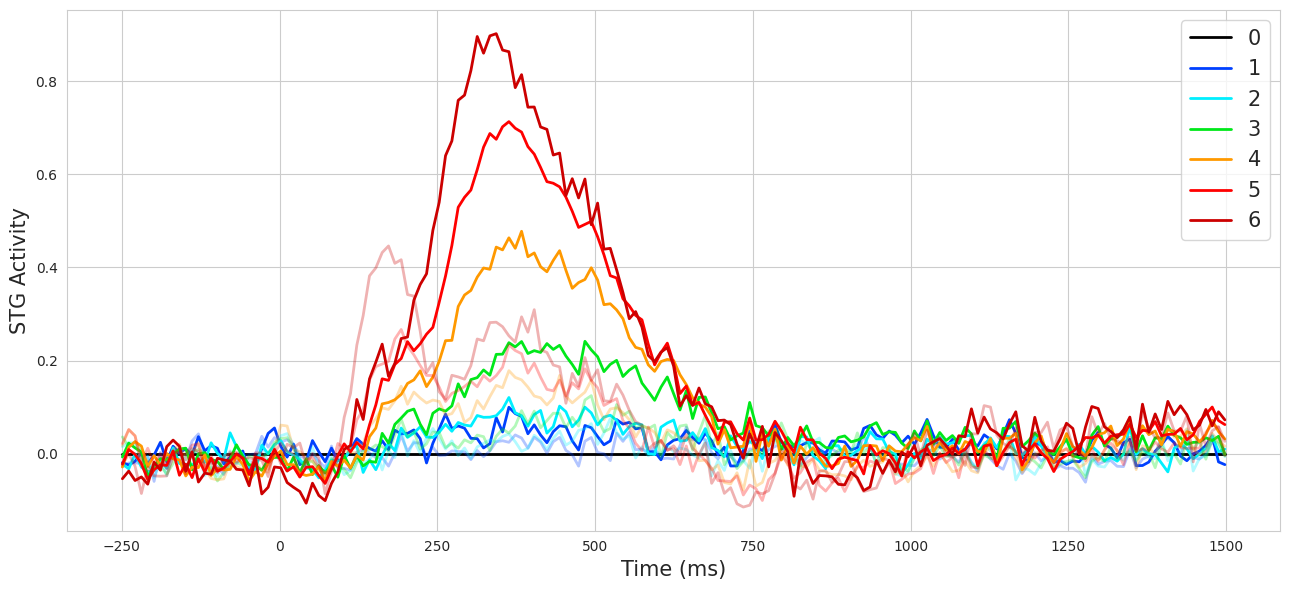

In [19]:
from matplotlib.colors import ListedColormap, Normalize

times = np.linspace(-500, 2000, 250)

plt.figure(figsize=(13, 6))
sns.set_style('whitegrid')

custom_colors = [colormap[i] for i in range(7)]
cmap = ListedColormap(custom_colors, name='snr_custom')
norm = Normalize(vmin=0, vmax=6)

for snr in range(7):
    signal = state_train_dict_passive[snr].mean(axis=0)
    plt.plot(
        times[25:200],
        signal[25:200],
        color=colormap[snr],
        linewidth=2,
        alpha=1,
        label=str(snr)
    )

    signal_early = state_train_dict_passive_early[snr].mean(axis=0)
    plt.plot(
        times[25:200],
        signal_early[25:200],
        color=colormap[snr],
        linewidth=2,
        alpha=0.3,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
# colorbar = plt.colorbar(sm, ax=plt.gca(), pad=0.03, ticks=np.arange(1, 7))
# colorbar.set_label('SNR (dB)')
# colorbar.set_ticklabels([str(level) for level in snr_levels])

plt.xlabel('Time (ms)', fontsize=15)
plt.ylabel('STG Activity', fontsize=15)
# plt.title(f'STG Activity by SNR', fontsize=12)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

In [20]:
inter_trial_std_dict_passive = {snr: [] for snr in range(7)}
for part in tqdm(range(20)):
    max_snr = 7 if part>=10 else 6
    for snr in range(max_snr):
        inter_trial_std = np.std(state_train_all_parts_passive[part][snr], axis=0)
        # print(f"Part {part}, SNR {snr}: inter_trial_std shape: {inter_trial_std.shape}")
        inter_trial_std_dict_passive[snr].append(inter_trial_std)

for snr in inter_trial_std_dict_passive.keys():
    inter_trial_std_dict_passive[snr] = np.array(inter_trial_std_dict_passive[snr])

# 95% confidence interval for the variability mean at each SNR level.
# Most common approach: mean +/- 1.96 * SEM, where SEM = SD / sqrt(n)
window = (times >= 400) & (times <= 500)

mean_variability_by_snr_passive = []
ci95_by_snr_passive = []

for snr in range(7):
    if inter_trial_std_dict_passive[snr].size == 0:
        mean_variability_by_snr_passive.append(np.nan)
        ci95_by_snr_passive.append(np.nan)
        continue

    subject_window_means = np.array([
        np.mean(subj_std[window])
        for subj_std in inter_trial_std_dict_passive[snr]
    ])

    mean_val = subject_window_means.mean()
    if subject_window_means.size > 1:
        sem = subject_window_means.std(ddof=1) / np.sqrt(subject_window_means.size)
        ci95 = 1.96 * sem
    else:
        ci95 = 0.0

    mean_variability_by_snr_passive.append(mean_val)
    ci95_by_snr_passive.append(ci95)


  0%|          | 0/20 [00:00<?, ?it/s]

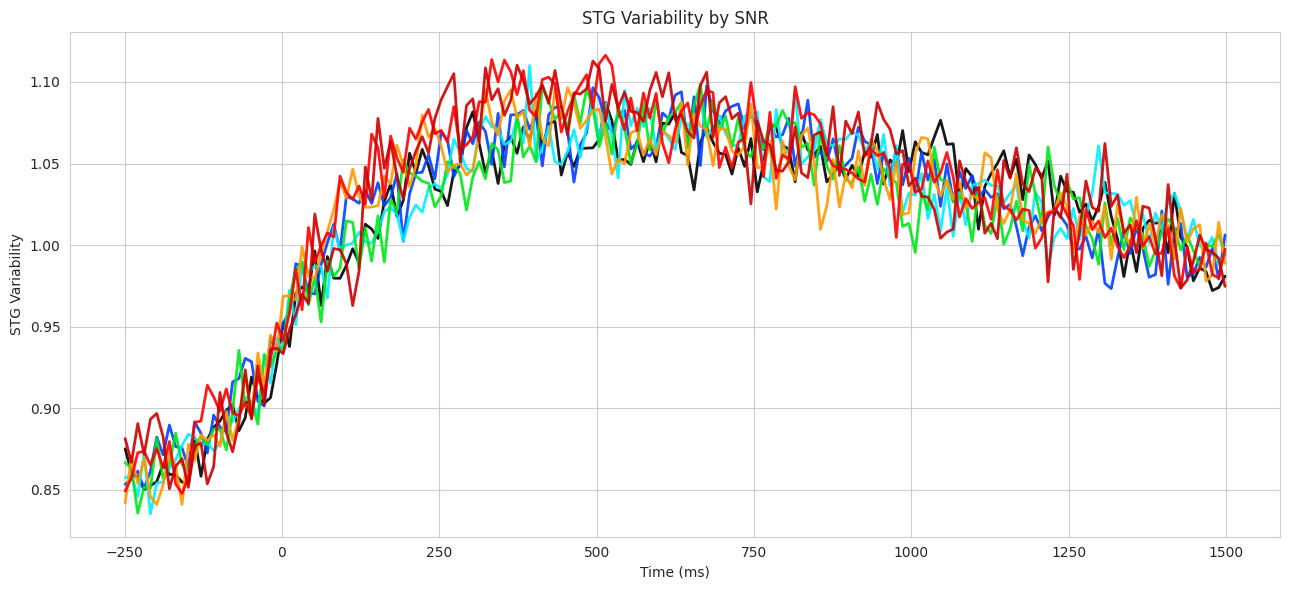

In [21]:
times = np.linspace(-500, 2000, 250)

plt.figure(figsize=(13, 6))
sns.set_style('whitegrid')

snr_levels = [-13, -11, -9, -7, -5, -3]
custom_colors = [colormap[i] for i in range(1, 7)]
cmap = ListedColormap(custom_colors, name='snr_custom')
norm = Normalize(vmin=1, vmax=6)

for snr in range(7):
    signal = inter_trial_std_dict_passive[snr].mean(axis=0)
    plt.plot(
        times[25:200],
        signal[25:200],
        color=colormap[snr],
        linewidth=2,
        alpha=0.9,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
# colorbar = plt.colorbar(sm, ax=plt.gca(), pad=0.03)
# colorbar.set_label('SNR')
# colorbar.set_ticks(np.arange(1, 7))
# colorbar.set_ticklabels([str(level) for level in snr_levels])

plt.xlabel('Time (ms)')
plt.ylabel('STG Variability')
plt.title(f'STG Variability by SNR')
plt.tight_layout()
plt.show()

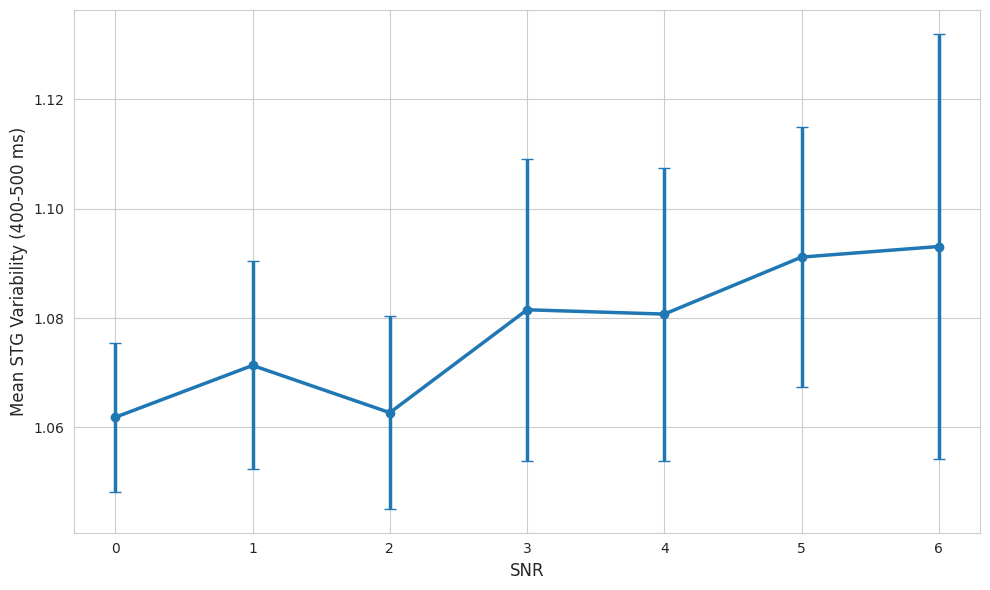

In [22]:
mean_variability_by_snr_passive = np.asarray(mean_variability_by_snr_passive, dtype=float)
ci95_by_snr_passive = np.asarray(ci95_by_snr_passive, dtype=float)
valid = ~np.isnan(mean_variability_by_snr_passive)

plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

plt.errorbar(
    np.arange(0, 7)[valid],
    mean_variability_by_snr_passive[valid],
    yerr=ci95_by_snr_passive[valid],
    fmt='o-',
    capsize=4,
    markersize=6,
    linewidth=2.5,
    color='C0',
    label='Mean ± 95% CI'
)

plt.xticks(np.arange(7))
plt.xlabel('SNR', fontsize=12)
plt.ylabel('Mean STG Variability (400-500 ms)', fontsize=12)
# plt.title('STG Variability Averaged Over 400-500 ms by SNR')
# plt.legend()
plt.tight_layout()
plt.show()

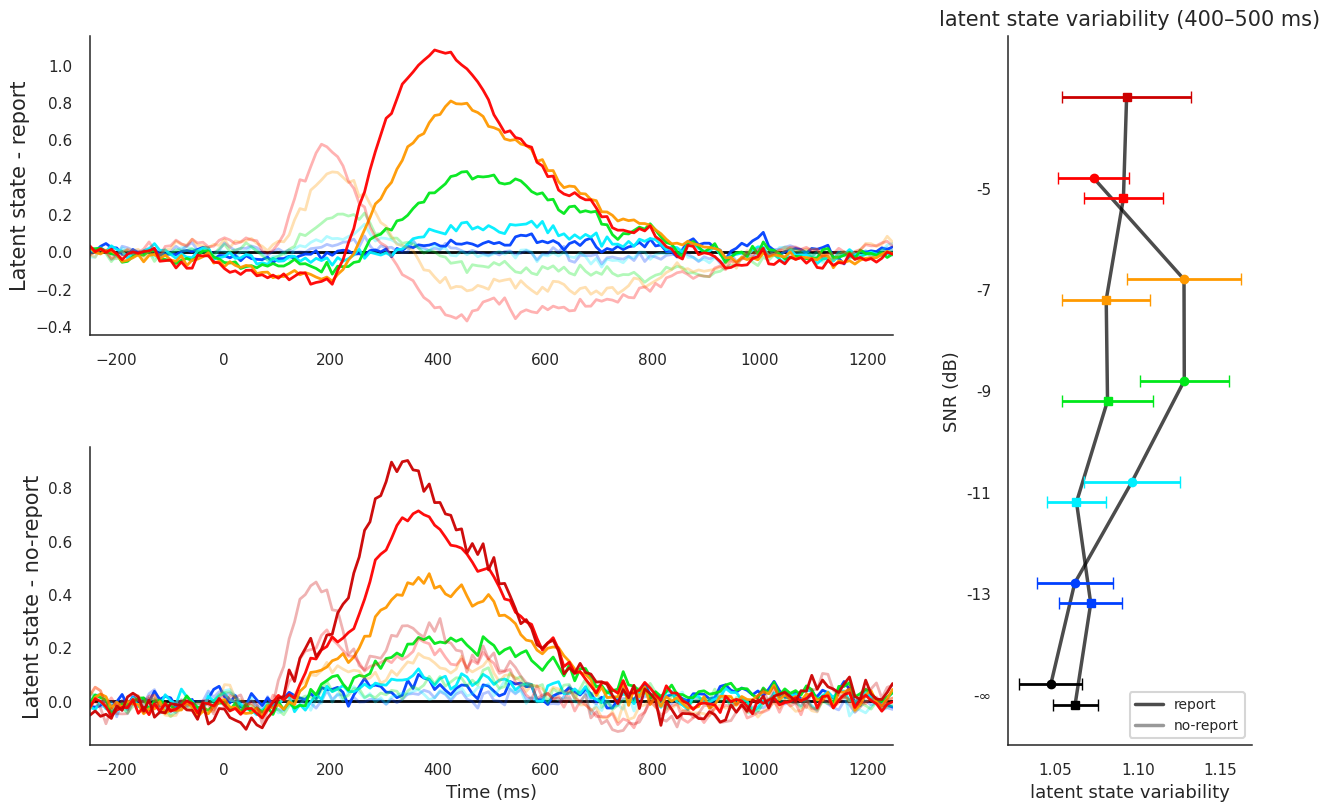

In [23]:
# Final publication-ready figure using only the arrays computed earlier in the notebook.
sns.set_theme(style="white", context="talk")
plt.rcParams.update({
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "axes.linewidth": 1.1,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
})

passive_colors = [colormap[i] for i in range(7)]
passive_cmap = ListedColormap(passive_colors, name="snr_custom")
passive_norm = Normalize(vmin=0, vmax=6)

snr_colors = [colormap[i] for i in range(1, 7)]
snr_cmap = ListedColormap(snr_colors, name="snr_active")
snr_norm = Normalize(vmin=1, vmax=6)

fig = plt.figure(figsize=(12.5, 8), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.15, 1.15], width_ratios=[3.3, 1.0], wspace=0.08, hspace=0.10)

ax_act = fig.add_subplot(gs[0, 0])
ax_pas = fig.add_subplot(gs[1, 0], sharex=ax_act)
ax_var = fig.add_subplot(gs[:, 1])

# Top left: Report dynamics (snr_sorted active) with early dynamics
for snr in range(1, 7):
    signal = state_train_dict_snrwise[snr].mean(axis=0)
    ax_act.plot(
        times[25:175],
        signal[25:175],
        color=colormap[snr-1],
        linewidth=2.0,
        alpha=0.95,
    )
    
    signal_early = state_train_dict_snrwise_early[snr].mean(axis=0)
    ax_act.plot(
        times[25:175],
        signal_early[25:175],
        color=colormap[snr-1],
        linewidth=2.0,
        alpha=0.3,
    )

# ax_act.set_title("Report dynamics", pad=8)
ax_act.set_ylabel("Latent state - report", fontsize=15)
ax_act.set_xlim(times[25], times[174])
ax_act.spines["top"].set_visible(False)
ax_act.spines["right"].set_visible(False)
ax_act.tick_params(direction="out")

# Bottom left: No-report dynamics (passive) with early dynamics
for snr in range(7):
    signal = state_train_dict_passive[snr].mean(axis=0)
    ax_pas.plot(
        times[25:175],
        signal[25:175],
        color=passive_cmap(passive_norm(snr)),
        linewidth=2.0,
        alpha=0.95,
    )
    
    signal_early = state_train_dict_passive_early[snr].mean(axis=0)
    ax_pas.plot(
        times[25:175],
        signal_early[25:175],
        color=passive_cmap(passive_norm(snr)),
        linewidth=2.0,
        alpha=0.3,
    )

# ax_pas.set_title("No-report dynamics", pad=8)
ax_pas.set_xlabel("Time (ms)")
ax_pas.set_ylabel("Latent state - no-report", fontsize=15)
ax_pas.set_xlim(times[25], times[174])
ax_pas.spines["top"].set_visible(False)
ax_pas.spines["right"].set_visible(False)
ax_pas.tick_params(direction="out")

# Right: latent state variability for both report and no-report with curves
# Report variability
valid_snr = ~np.isnan(mean_variability_by_snr)
y_snr = np.arange(len(mean_variability_by_snr))[valid_snr]
var_snr = mean_variability_by_snr[valid_snr]
ci_snr = ci95_by_snr[valid_snr]
report_colors = [colormap[i] for i in y_snr]
report_y = y_snr + 0.1

# No-report variability
valid_passive = ~np.isnan(mean_variability_by_snr_passive)
y_passive = np.arange(len(mean_variability_by_snr_passive))[valid_passive]
var_passive = mean_variability_by_snr_passive[valid_passive]
ci_passive = ci95_by_snr_passive[valid_passive]
passive_plot_colors = [colormap[i] for i in y_passive]
passive_y = y_passive - 0.1

# Plot lines for both groups with slight vertical offsets to avoid overlapping error bars.
ax_var.plot(var_snr, report_y, color='black', linewidth=2.5, alpha=0.7, zorder=2)
for x, y, xerr, color in zip(var_snr, report_y, ci_snr, report_colors):
    ax_var.errorbar(
        x,
        y,
        xerr=xerr,
        fmt='o',
        capsize=4,
        markersize=6,
        color=color,
        ecolor=color,
        elinewidth=2.0,
        markerfacecolor=color,
        markeredgecolor=color,
        zorder=3,
    )

ax_var.plot(var_passive, passive_y, color='black', linewidth=2.5, alpha=0.7, zorder=2)
for x, y, xerr, color in zip(var_passive, passive_y, ci_passive, passive_plot_colors):
    ax_var.errorbar(
        x,
        y,
        xerr=xerr,
        fmt='s',
        capsize=4,
        markersize=6,
        color=color,
        ecolor=color,
        elinewidth=2.0,
        markerfacecolor=color,
        markeredgecolor=color,
        zorder=3,
    )

# Add a single legend entry for each group after plotting the points
ax_var.plot([], [], color='black', linewidth=2.5, alpha=0.7, label='report')
ax_var.plot([], [], color='black', linewidth=2.5, alpha=0.4, label='no-report')
ax_var.legend(loc='lower right', frameon=True)

snr_labels = np.array(["-∞", "-13", "-11", "-9", "-7", "-5", "-3"])
ax_var.set_yticks(y_snr)
ax_var.set_yticklabels([snr_labels[i] for i in y_snr])
ax_var.set_xlabel("latent state variability")
ax_var.set_ylabel("SNR (dB)")
ax_var.set_title("latent state variability (400–500 ms)", pad=8)
ax_var.set_ylim(-0.5, max(y_snr.max(), y_passive.max()) + 0.5)
ax_var.legend(loc='lower right', frameon=True)
ax_var.spines["top"].set_visible(False)
ax_var.spines["right"].set_visible(False)
ax_var.tick_params(direction="out")

plt.show()


# Psychometric curves

In [28]:
psychometric_all_parts = {'Active':[], 'Passive': []}
for part in tqdm(range(20)):

    # for 'Active', audibility is directly asked, and we consider the target heard for aud >= 3.
    task = 'Active'
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref
    # Load metadata
    epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
    audibility = epochs.metadata['audibility'].to_numpy()
    snr = epochs.metadata['snr'].to_numpy()
    heard = np.array([np.sum(audibility[snr==snr_val] >= 3) for snr_val in range(1,7)])
    not_heard = np.array([np.sum(audibility[snr==snr_val] < 3) for snr_val in range(1,7)])
    psychometric_all_parts[task].append((heard / (heard + not_heard)))

    # for 'Passive', the MindWandering question (questiontype=3) sometimes asks if the mind content is the target (response=1)
    task = 'Passive'
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref
    # Load metadata
    epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
    valid_trials = epochs.metadata['questiontype'].to_numpy() == 3
    snr = epochs.metadata['snr'].to_numpy()[valid_trials]
    response = epochs.metadata['response'].to_numpy()[valid_trials]
    heard = np.array([np.sum(response[snr==snr_val] == 1) for snr_val in range(1,8)])
    not_heard = np.array([np.sum(response[snr==snr_val] != 1) for snr_val in range(1,8)])
    psychometric_all_parts[task].append((heard / (heard + not_heard)))

  0%|          | 0/20 [00:00<?, ?it/s]

/tmp/ipykernel_323590/3985422549.py:9: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_323590/3985422549.py:21: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_323590/3985422549.py:27: RuntimeWarning: invalid value encountered in divide
  psychometric_all_parts[task].append((heard / (heard + not_heard)))
/tmp/ipykernel_323590/3985422549.py:9: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can 

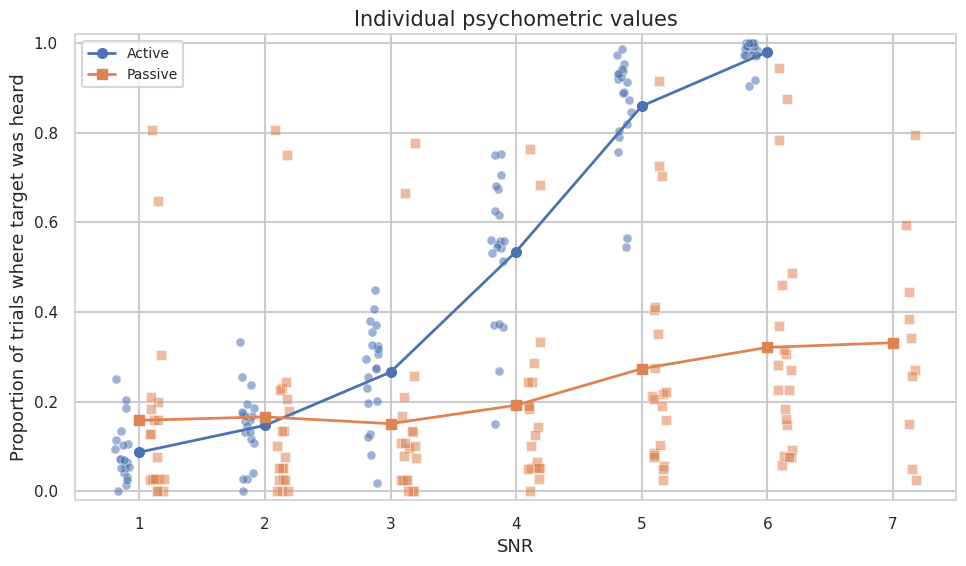

In [39]:
# Rain plot of individual psychometric values by SNR.
# Individual observations are jittered horizontally; no subject-level lines are drawn.
rng = np.random.default_rng(42)

fig, ax = plt.subplots(figsize=(10, 6))
sns.set_style('whitegrid')

psychometric_colors = {'Active': 'C0', 'Passive': 'C1'}
psychometric_markers = {'Active': 'o', 'Passive': 's'}
psychometric_offsets = {'Active': -0.14, 'Passive': 0.14}

for task, values in psychometric_all_parts.items():
    values = np.asarray(values, dtype=float)
    for snr_index in range(values.shape[1]):
        valid_values = values[:, snr_index]
        valid_values = valid_values[~np.isnan(valid_values)]
        x = (
            snr_index + 1
            + psychometric_offsets[task]
            + rng.uniform(-0.06, 0.06, size=valid_values.size)
        )
        ax.scatter(
            x,
            valid_values,
            color=psychometric_colors[task],
            marker=psychometric_markers[task],
            alpha=0.55,
            s=42,
            edgecolors='white',
            linewidths=0.5,
            # label=task if snr_index == 0 else None,
        )

    mean_values = np.nanmean(values, axis=0)
    ax.plot(
        np.arange(1, values.shape[1] + 1),
        mean_values,
        color=psychometric_colors[task],
        marker=psychometric_markers[task],
        linewidth=2,
        markersize=7,
        label=f'{task}',
    )

ax.set_xticks(np.arange(1, 8))
ax.set_xlabel('SNR')
ax.set_ylabel('Proportion of trials where target was heard')
ax.set_ylim(-0.02, 1.02)
ax.set_title('Individual psychometric values')
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

In [41]:
passive_values = np.asarray(psychometric_all_parts['Passive'], dtype=float)[:, 6]
print(
    "Passive, SNR 7's value is {:.3f} ± {:.3f}".format(
        np.nanmean(passive_values),
        np.nanstd(passive_values),
    )
)

Passive, SNR 7's value is 0.331 ± 0.227
